# Notebook 07 — Temperature Model Audit

## Goal

This notebook audits how temperature enters the current PyBaMM aging-bridge workflow.

The purpose is not to run a full temperature matrix, but to answer four entry-level questions:

1. What is the default temperature in the Chen2020 parameter set?
2. Is the current DFN setup isothermal?
3. Which parameters explicitly reference temperature?
4. Does changing temperature modify baseline HPPC observables such as Ri and tau descriptors?

## Scientific context

Previous notebooks established mechanism-to-observable fingerprints under a fixed default isothermal condition.

However, temperature is a critical operating-condition layer in lithium-ion battery diagnostics. It can affect:

- short-window resistance,
- exchange-current density,
- solid and electrolyte diffusion,
- relaxation time constants,
- voltage response,
- plating susceptibility.

Before expanding to multi-SOC or multi-temperature fingerprint scans, the temperature entry point must be audited.

## Workflow

1. Import packages and audit paths.
2. Inspect default temperature-related parameters in Chen2020.
3. Inspect DFN thermal options.
4. Identify callable parameter functions whose signatures include temperature.
5. Run a small baseline HPPC temperature sensitivity test:
   - 10 °C
   - 25 °C
   - 45 °C
6. Extract:
   - Ri_CD / Ri_EF
   - tau2_60s / tau2_300s
7. Plot temperature-dependent observable drift.

## Expected outputs

- `data/temperature_model_audit_hppc_results.csv`
- temperature parameter audit table
- baseline HPPC observable comparison across temperatures
- Ri vs temperature plot
- tau2 vs temperature plot

## Interpretation boundary

This notebook does not establish a complete thermal-aging model.

It only tests whether temperature is active in the current PyBaMM DFN workflow and whether changing temperature affects baseline HPPC observables.

If temperature affects Ri or tau descriptors, later mechanism-to-observable scans must treat temperature as an independent operating-condition layer.

In [1]:
# Cell 1 — Imports and path audit（导入库并确认项目路径）

from pathlib import Path
import inspect

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

from scipy.optimize import curve_fit

print("PyBaMM version:", pybamm.__version__)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"
FIGURES = ROOT / "figures"

DATA.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("DATA:", DATA)
print("FIGURES:", FIGURES)

PyBaMM version: 26.3.1
ROOT: /Users/louislu/projects/pybamm-aging-bridge
DATA: /Users/louislu/projects/pybamm-aging-bridge/data
FIGURES: /Users/louislu/projects/pybamm-aging-bridge/figures


In [2]:
# Cell 2 — Temperature parameter audit（审计 Chen2020 中与温度相关的参数）

param = pybamm.ParameterValues("Chen2020")

temperature_rows = []

for key in param.keys():
    if "temperature" in key.lower():
        temperature_rows.append(
            {
                "parameter": key,
                "value": param[key],
                "type": type(param[key]).__name__,
            }
        )

temperature_param_table = pd.DataFrame(temperature_rows)

display(temperature_param_table)

out_csv = DATA / "temperature_parameter_audit.csv"
temperature_param_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)

,parameter,value,type
0,Reference temperature [K],298.15,float
1,Ambient temperature [K],298.15,float
2,Initial temperature [K],298.15,float


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/temperature_parameter_audit.csv


In [3]:
# Cell 3 — DFN option audit（检查 DFN 默认热模型选项）

model_default = pybamm.lithium_ion.DFN()

thermal_related_options = {
    k: v
    for k, v in model_default.options.items()
    if "thermal" in str(k).lower()
    or "temperature" in str(k).lower()
    or "heat" in str(k).lower()
}

display(pd.DataFrame(
    [
        {"option": k, "value": v}
        for k, v in thermal_related_options.items()
    ]
))

print("Full thermal option:", model_default.options["thermal"])
print("Surface temperature option:", model_default.options["surface temperature"])

,option,value
0,calculate heat source for isothermal models,false
1,heat of mixing,false
2,surface temperature,ambient
3,thermal,isothermal
4,use lumped thermal capacity,false


Full thermal option: isothermal
Surface temperature option: ambient


In [4]:
# Cell 4 — Callable parameters with temperature signature（查找签名中显式包含温度变量的参数函数）

temperature_callable_rows = []

for key in param.keys():
    value = param[key]

    if callable(value):
        try:
            sig = inspect.signature(value)
            sig_text = str(sig)

            has_temperature_arg = (
                "T" in sig_text
                or "temperature" in sig_text.lower()
            )

            if has_temperature_arg:
                temperature_callable_rows.append(
                    {
                        "parameter": key,
                        "signature": sig_text,
                        "type": type(value).__name__,
                    }
                )

        except Exception as e:
            pass

temperature_callable_table = pd.DataFrame(temperature_callable_rows)

display(temperature_callable_table)

out_csv = DATA / "temperature_callable_parameter_audit.csv"
temperature_callable_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)

,parameter,signature,type
0,Negative electrode exchange-current density [A...,"(c_e, c_s_surf, c_s_max, T)",function
1,Positive electrode exchange-current density [A...,"(c_e, c_s_surf, c_s_max, T)",function
2,Electrolyte diffusivity [m2.s-1],"(c_e, T)",function
3,Electrolyte conductivity [S.m-1],"(c_e, T)",function


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/temperature_callable_parameter_audit.csv


In [5]:
# Cell 5 — Shared HPPC extraction configuration（统一 HPPC 仿真与提取配置）

SOC_INIT = 0.50
PULSE_C_RATE = "1C"
PULSE_DURATION_S = 10
REST_BEFORE_S = 60
RELAXATION_S = 600
OUTPUT_PERIOD = "0.1 seconds"

COMMON_MODEL_OPTIONS = {
    "contact resistance": "true",
}

print("SOC_INIT:", SOC_INIT)
print("Pulse:", PULSE_C_RATE, "for", PULSE_DURATION_S, "s")
print("Relaxation:", RELAXATION_S, "s")
print("Model options:", COMMON_MODEL_OPTIONS)

SOC_INIT: 0.5
Pulse: 1C for 10 s
Relaxation: 600 s
Model options: {'contact resistance': 'true'}


In [6]:
# Cell 6 — Minimal HPPC runner and extraction functions（最小 HPPC 仿真与可观测量提取函数）

def make_temperature_param(T_K):
    p = pybamm.ParameterValues("Chen2020")

    for key in ["Ambient temperature [K]", "Initial temperature [K]"]:
        if key in p.keys():
            p.update({key: T_K})

    return p


def run_temperature_hppc_case(case_name, T_K):
    p = make_temperature_param(T_K)

    model = pybamm.lithium_ion.DFN(COMMON_MODEL_OPTIONS)

    experiment = pybamm.Experiment(
        [
            f"Rest for {REST_BEFORE_S} seconds",
            f"Discharge at {PULSE_C_RATE} for {PULSE_DURATION_S} seconds",
            f"Rest for {RELAXATION_S} seconds",
        ],
        period=OUTPUT_PERIOD,
    )

    sim = pybamm.Simulation(
        model,
        parameter_values=p,
        experiment=experiment,
    )

    sim.set_initial_soc(SOC_INIT, direction="discharge")
    sol = sim.solve()

    df = pd.DataFrame(
        {
            "case": case_name,
            "temperature_K": T_K,
            "temperature_C": T_K - 273.15,
            "time_s": sol["Time [s]"].entries,
            "voltage_V": sol["Terminal voltage [V]"].entries,
            "current_A_pybamm": sol["Current [A]"].entries,
        }
    )

    df["time_rel_s"] = df["time_s"] - df["time_s"].iloc[0]
    df["current_A_exp"] = -df["current_A_pybamm"]

    return df, sol


def extract_cdefg_and_ri_minimal(df):
    t = df["time_rel_s"].values
    u = df["voltage_V"].values
    i = df["current_A_pybamm"].values

    pulse_mask = np.abs(i) > 0.1
    pulse_indices = np.where(pulse_mask)[0]

    if len(pulse_indices) == 0:
        raise ValueError("No pulse detected.")

    t_start = float(t[pulse_indices[0]])
    t_end = float(t[pulse_indices[-1]])

    C_window = (t >= t_start - 1.0) & (t < t_start)
    D_window = (t >= t_start + 0.1) & (t <= t_start + 0.3)
    E_window = (t >= t_end - 0.3) & (t <= t_end)
    F_window = (t > t_end) & (t <= t_end + 0.3)
    G_window = (t >= t_end + RELAXATION_S - 10) & (t <= t_end + RELAXATION_S)

    U_C = np.median(u[C_window])
    U_D = np.median(u[D_window])
    U_E = np.median(u[E_window])
    U_F = np.median(u[F_window])
    U_G = np.median(u[G_window])

    I_C = np.median(i[C_window])
    I_D = np.median(i[D_window])
    I_E = np.median(i[E_window])
    I_F = np.median(i[F_window])

    Ri_CD_mohm = abs((U_D - U_C) / (I_D - I_C)) * 1000
    Ri_EF_mohm = abs((U_F - U_E) / (I_F - I_E)) * 1000

    return {
        "pulse_start_s": t_start,
        "pulse_end_s": t_end,
        "Ri_CD_mohm": Ri_CD_mohm,
        "Ri_EF_mohm": Ri_EF_mohm,
        "C_U_V": U_C,
        "D_U_V": U_D,
        "E_U_V": U_E,
        "F_U_V": U_F,
        "G_U_V": U_G,
    }


def fit_biexp_with_window_minimal(relax, fit_t_min=0.5, fit_t_max=60.0, tail_start_s=550.0):
    fit_mask = (
        (relax["t_relax_s"] >= fit_t_min)
        & (relax["t_relax_s"] <= fit_t_max)
    )

    t_fit = relax.loc[fit_mask, "t_relax_s"].values
    u_fit = relax.loc[fit_mask, "voltage_V"].values

    tail_mask = relax["t_relax_s"] >= tail_start_s
    Uinf = float(np.median(relax.loc[tail_mask, "voltage_V"]))

    def biexp(t, A1, tau1, A2, tau2):
        return Uinf - A1 * np.exp(-t / tau1) - A2 * np.exp(-t / tau2)

    A_total = Uinf - u_fit[0]

    p0 = [0.6 * A_total, 3.0, 0.4 * A_total, 30.0]
    bounds = ([0.0, 0.1, 0.0, 1.0], [1.0, 100.0, 1.0, 1000.0])

    popt, _ = curve_fit(
        biexp,
        t_fit,
        u_fit,
        p0=p0,
        bounds=bounds,
        maxfev=20000,
    )

    A1, tau1, A2, tau2 = popt

    if tau1 > tau2:
        A1, A2 = A2, A1
        tau1, tau2 = tau2, tau1

    u_pred = biexp(t_fit, A1, tau1, A2, tau2)
    residual = u_fit - u_pred

    rmse_mV = np.sqrt(np.mean(residual**2)) * 1000

    return {
        "tau1_s": float(tau1),
        "tau2_s": float(tau2),
        "RMSE_mV": float(rmse_mV),
    }


def extract_temperature_hppc_observables(df):
    base = extract_cdefg_and_ri_minimal(df)

    t_end = base["pulse_end_s"]

    relax = df[
        (df["time_rel_s"] > t_end)
        & (df["time_rel_s"] <= t_end + RELAXATION_S)
    ].copy()

    relax["t_relax_s"] = relax["time_rel_s"] - t_end

    fit60 = fit_biexp_with_window_minimal(relax, fit_t_max=60.0)
    fit300 = fit_biexp_with_window_minimal(relax, fit_t_max=300.0)

    out = dict(base)
    out["biexp60_tau1_s"] = fit60["tau1_s"]
    out["biexp60_tau2_s"] = fit60["tau2_s"]
    out["biexp60_RMSE_mV"] = fit60["RMSE_mV"]
    out["biexp300_tau1_s"] = fit300["tau1_s"]
    out["biexp300_tau2_s"] = fit300["tau2_s"]
    out["biexp300_RMSE_mV"] = fit300["RMSE_mV"]

    return out, relax

print("[OK] temperature HPPC runner and extraction helpers defined")

[OK] temperature HPPC runner and extraction helpers defined


In [7]:
# Cell 7 — Temperature sensitivity smoke run（10/25/45°C 下 baseline HPPC 小扫描）

temperature_cases = [
    {"case": "baseline_T10C", "T_K": 283.15},
    {"case": "baseline_T25C", "T_K": 298.15},
    {"case": "baseline_T45C", "T_K": 318.15},
]

temperature_results = []
temperature_dfs = {}
temperature_relax = {}

for spec in temperature_cases:
    case = spec["case"]
    T_K = spec["T_K"]

    print(f"\n=== Running {case} | T = {T_K - 273.15:.1f} °C ===")

    df_case, _ = run_temperature_hppc_case(case, T_K)
    obs, relax = extract_temperature_hppc_observables(df_case)

    obs["case"] = case
    obs["temperature_K"] = T_K
    obs["temperature_C"] = T_K - 273.15
    obs["status"] = "ok"

    temperature_results.append(obs)
    temperature_dfs[case] = df_case
    temperature_relax[case] = relax

    print("[OK]", case)
    print(f"Ri_CD = {obs['Ri_CD_mohm']:.3f} mΩ")
    print(f"tau2_60s = {obs['biexp60_tau2_s']:.3f} s")
    print(f"tau2_300s = {obs['biexp300_tau2_s']:.3f} s")

temperature_table = pd.DataFrame(temperature_results)

out_csv = DATA / "temperature_model_audit_hppc_results.csv"
temperature_table.to_csv(out_csv, index=False)

print("\n[OK] saved:", out_csv)
display(temperature_table)


=== Running baseline_T10C | T = 10.0 °C ===
[OK] baseline_T10C
Ri_CD = 30.644 mΩ
tau2_60s = 49.285 s
tau2_300s = 107.212 s

=== Running baseline_T25C | T = 25.0 °C ===
[OK] baseline_T25C
Ri_CD = 23.545 mΩ
tau2_60s = 48.698 s
tau2_300s = 107.086 s

=== Running baseline_T45C | T = 45.0 °C ===
[OK] baseline_T45C
Ri_CD = 15.926 mΩ
tau2_60s = 47.861 s
tau2_300s = 107.244 s

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/temperature_model_audit_hppc_results.csv


,pulse_start_s,pulse_end_s,Ri_CD_mohm,Ri_EF_mohm,C_U_V,D_U_V,E_U_V,F_U_V,G_U_V,biexp60_tau1_s,biexp60_tau2_s,biexp60_RMSE_mV,biexp300_tau1_s,biexp300_tau2_s,biexp300_RMSE_mV,case,temperature_K,temperature_C,status
0,60.0,70.0,30.644061,30.102541,3.750874,3.597653,3.572400,3.722913,3.747969,9.475319,49.285057,0.037035,18.273789,107.212259,0.148433,baseline_T10C,283.15,10.0,ok
1,60.0,70.0,23.545486,22.969868,3.750874,3.633146,3.607630,3.722479,3.747969,9.440863,48.698375,0.038401,18.331299,107.085635,0.150494,baseline_T25C,298.15,25.0,ok
2,60.0,70.0,15.926339,15.431773,3.750874,3.671242,3.644807,3.721966,3.747967,9.388406,47.860775,0.042549,18.252245,107.244245,0.152217,baseline_T45C,318.15,45.0,ok


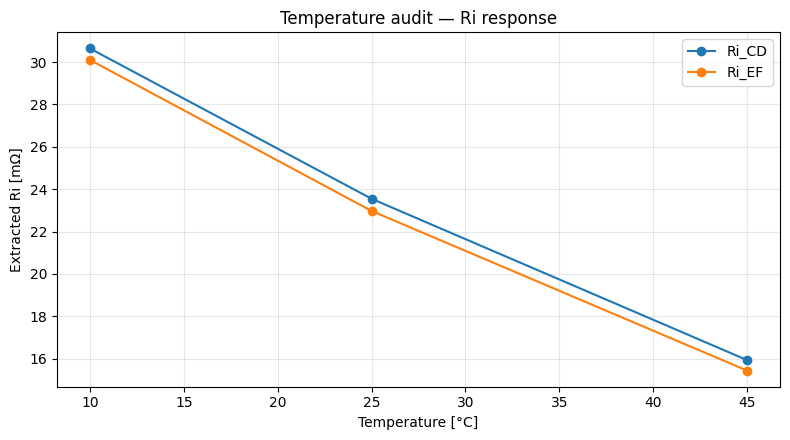

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/temperature_audit_Ri_response.png


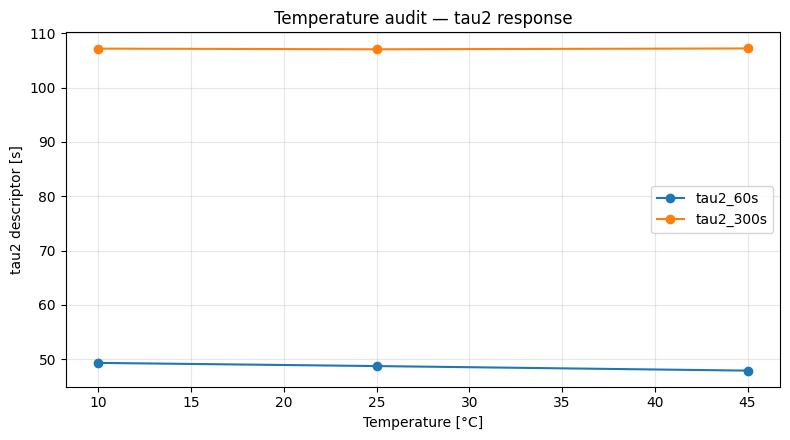

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/temperature_audit_tau2_response.png


In [8]:
# Cell 8 — Temperature response plots（绘制温度对 Ri 与 tau2 的影响）

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(
    temperature_table["temperature_C"],
    temperature_table["Ri_CD_mohm"],
    marker="o",
    label="Ri_CD",
)

ax.plot(
    temperature_table["temperature_C"],
    temperature_table["Ri_EF_mohm"],
    marker="o",
    label="Ri_EF",
)

ax.set_xlabel("Temperature [°C]")
ax.set_ylabel("Extracted Ri [mΩ]")
ax.set_title("Temperature audit — Ri response")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "temperature_audit_Ri_response.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)


fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(
    temperature_table["temperature_C"],
    temperature_table["biexp60_tau2_s"],
    marker="o",
    label="tau2_60s",
)

ax.plot(
    temperature_table["temperature_C"],
    temperature_table["biexp300_tau2_s"],
    marker="o",
    label="tau2_300s",
)

ax.set_xlabel("Temperature [°C]")
ax.set_ylabel("tau2 descriptor [s]")
ax.set_title("Temperature audit — tau2 response")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "temperature_audit_tau2_response.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)